In [1]:
import numpy as np
import sys
from pathlib import Path
project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))
from beam_properties import PiezoBeamParams
from FE1 import PiezoBeamFE, frf_sweep
import matplotlib.pyplot as plt
from Reduced_order.ROM import ROM
from numpy import pi	
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd


ModuleNotFoundError: No module named 'beam_properties'

In [ ]:
params_fe.rho_s

2700.0

In [ ]:
# # ======= K_p sweep in frequency domain =======
K_i = 2000; K_p = 0.008; K_c = 0
t_end = 0.01
f0 = 1000
f1 = 4500
N = 40

# hp, hs = 0.31e-3, 0.607e-3 		
params_fe = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)
params_fe.zeta_p = 0.0151*2*2*1.2
params_fe.zeta_q = 0.0392*2*2*1.6

params_rom = PiezoBeamParams(hp=0.23e-3, hs=0.5e-3, rho_p=8500)


def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)

rom = ROM(params=params_rom, N=N)

# x0 = np.zeros(2*N + 2*S
t_eval = np.arange(0, t_end, 1/f1/20)
x_eval = np.linspace(0, rom.p.L_b, 100)

results = rom.run_time_sim(v_exc=v_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

freq_modal, vel_mag, disp_mag = rom.frequency_response(K_c=K_c, K_p=K_p, K_i=K_i)

# compute FRF
fe = PiezoBeamFE(params_fe, n_el_gap=1,n_el_patch=3)
ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
)
f_fe = np.linspace(f0, f1, 500)
X = frf_sweep(ode, f_fe*2*pi)
N = ode.N_mech
w = X[:, :N:2]   # transverse displacement


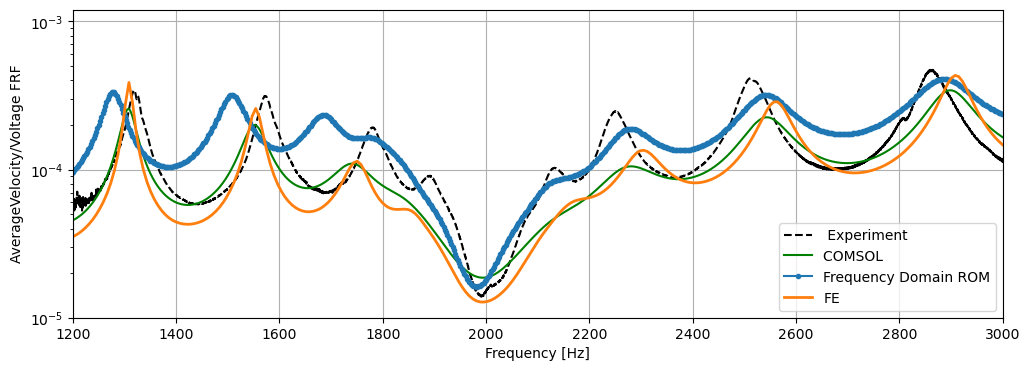

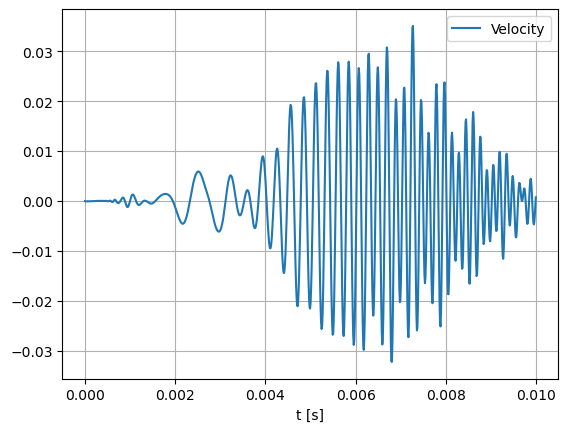

In [ ]:


# Load experimental data
npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
# npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\10\ki0_kc0_kpSweep\parametric_sweep.npz".replace("\\", "/")  
npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz".replace("\\", "/")  
# npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\10\hardening\linear.npz".replace("\\", "/")  
npz_path_OC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
npz_path_SC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\SC.npz".replace("\\", "/")
npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
data_SC = np.load(npz_path_SC)
data_OC = np.load(npz_path_OC)
data_linear = np.load(npz_path_linear)

frq_OC_exp = data_OC['freq']			# (Nfreq,)
frf_data_OC_exp = data_OC['frf_data']	# (Nfiles, Nfreq, Npoints)
frq_SC_exp = data_SC['freq']            # (Nfreq,)
frf_data_SC_exp = data_SC['frf_data']   # (Nfiles, Nfreq, Npoints)
frq_linear_exp = data_linear['freq']            # (Nfreq,)
frf_data_linear_exp = data_linear['frf_data']

comsol = pd.read_csv('../../comsol/LR.csv')
#%%


plt.figure(figsize=(12, 4))
plt.semilogy(frq_linear_exp, np.mean(frf_data_linear_exp[:,:], axis=1), 'k--', label=' Experiment')
plt.semilogy(comsol['freq'], comsol['w']*2*pi*comsol['freq'], 'g-', label='COMSOL ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC_exp, np.mean(frf_data_SC_exp[:,:], axis=1), 'k--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
# plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM'   )
# plt.semilogy(frq_OC_exp, np.mean(frf_data_OC_exp[:,:], axis=1), 'k--', label=f'Experiment')
plt.semilogy(f_fe, np.mean(np.abs(w), axis=1)*2*np.pi*f_fe/2, lw=2, label="FE")
# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')

# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )
plt.legend()
# plt.xlim([1300, 3000])
plt.xlim([1200, 3000])
# plt.ylim([1e-5, 1e-3])
plt.ylim([1e-5, 6e-4*2])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()





plt.figure()

# plt.plot(t, disp[10,:], '.-', label='Disp.')
plt.plot(t, veloc[10,:], '-', label='Velocity')
# plt.xlim([0, 0.05 ])
# plt.ylim(np.array([-1,1])*1e-3)

plt.xlabel("t [s]")
# plt.ylabel("displacement")
plt.legend()
plt.grid(True)


Eigenfrequency comparison (uniform beam)
Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]
------------------------------------------------
   1 |        5.3055 |    5.3197 |    5.6954
   2 |       33.2420 |   33.3351 |   35.6927
   3 |       93.0660 |   93.3322 |   99.9405
   4 |      182.3600 |  182.8809 |  195.8434
   5 |      301.4500 |  302.2956 |  323.7432
   6 |      450.3300 |  451.5508 |  483.6163
   7 |      629.0300 |  630.6454 |  675.4642
   8 |      837.5900 |  839.5777 |  899.2866
   9 |     1076.0000 | 1078.3472 | 1155.0837
  10 |     1344.4000 | 1346.9537 | 1442.8554
  11 |     1642.8000 | 1645.3976 | 1762.6017
  12 |     1971.1000 | 1973.6790 | 2114.3227
  13 |     2329.5000 | 2331.7970 | 2498.0183
  14 |     2717.8000 | 2719.7490 | 2913.6886
  15 |     3136.2000 | 3137.5287 | 3361.3335
  16 |     3584.5000 | 3585.1244 | 3840.9530
  17 |     4062.8000 | 4062.5159 | 4352.5472
  18 |     4570.8000 | 4569.6699 | 4896.1160
  19 |     5108.4000 | 5106.5338 | 5471.6594
  20 |  

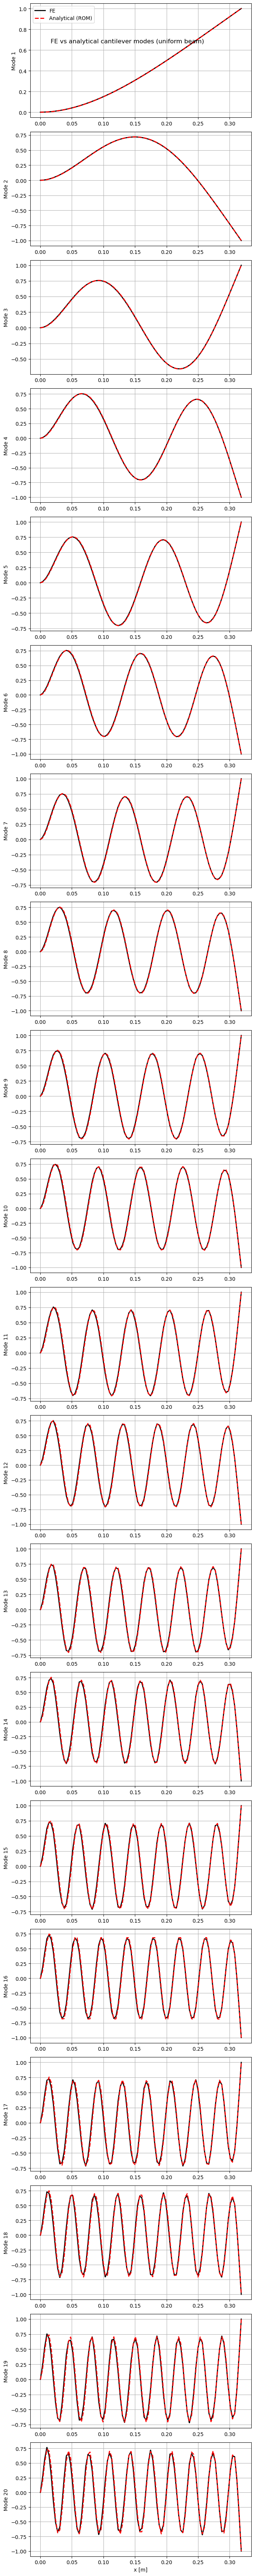


Modal Assurance Criterion (MAC)
Mode 1: MAC = 0.999997
Mode 2: MAC = 0.999972
Mode 3: MAC = 0.999906
Mode 4: MAC = 0.999789
Mode 5: MAC = 0.999618
Mode 6: MAC = 0.999385
Mode 7: MAC = 0.999086
Mode 8: MAC = 0.998713
Mode 9: MAC = 0.998261
Mode 10: MAC = 0.997723
Mode 11: MAC = 0.997092
Mode 12: MAC = 0.996363
Mode 13: MAC = 0.995529
Mode 14: MAC = 0.994582
Mode 15: MAC = 0.993515
Mode 16: MAC = 0.992322
Mode 17: MAC = 0.990992
Mode 18: MAC = 0.989515
Mode 19: MAC = 0.987880
Mode 20: MAC = 0.986069


In [ ]:
Nmodes_check = 20			# number of modes to compare
x_plot = fe.x_nodes			# FE nodal coordinates
w_dofs = np.arange(0, fe.Ndof, 2)		# transverse DOFs
freq, omega, Phi = fe.eigen_analysis()
# ----------------------------
# instantiate parameters + ROM
# ----------------------------
params = PiezoBeamParams()
rom = ROM(params, N=Nmodes_check)

# ----------------------------
# FE frequencies
# ----------------------------
f_fe = freq[:Nmodes_check]

# ----------------------------
# analytical frequencies (ROM-based)
# ----------------------------
omega_ana = rom.omega[:Nmodes_check]
f_ana = omega_ana / (2*np.pi)

# ----------------------------
# COMSOL reference frequencies
# ----------------------------
f_comsol = np.array([
	5.3055, 33.242, 93.066, 182.36, 301.45, 450.33, 629.03, 837.59,
	1076.0, 1344.4, 1642.8, 1971.1, 2329.5, 2717.8, 3136.2,
	3584.5, 4062.8, 4570.8, 5108.4, 5675.4, 6271.4, 6895.9, 7141.3
])

# ----------------------------
# frequency comparison table
# ----------------------------
print("\nEigenfrequency comparison (uniform beam)")
print("Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]")
print("------------------------------------------------")
for r in range(Nmodes_check):
	print(f"{r+1:4d} | {f_comsol[r]:13.4f} | {f_fe[r]:9.4f} | {f_ana[r]:9.4f}")

# ----------------------------
# mode shape comparison + MAC
# ----------------------------
MAC = np.zeros(Nmodes_check)

# consistent transverse mass matrix
Mw = fe.M[np.ix_(w_dofs, w_dofs)]

plt.figure(figsize=(7, 3.5*Nmodes_check))

for r in range(Nmodes_check):

	# FE transverse mode
	w_fe = Phi[w_dofs, r].copy()

	# analytical transverse mode (ROM)
	w_ana = rom.mode_shape(r, x_plot)

	# sign consistency
	if np.dot(w_fe, w_ana) < 0.0:
		w_ana *= -1.0

	# normalize by max amplitude (visual comparison)
	w_fe /= np.max(np.abs(w_fe))
	w_ana /= np.max(np.abs(w_ana))

	# MAC computation
	num = np.abs(w_fe @ Mw @ w_ana)**2
	den = (w_fe @ Mw @ w_fe) * (w_ana @ Mw @ w_ana)
	MAC[r] = num / den

	# plot
	plt.subplot(Nmodes_check, 1, r+1)
	plt.plot(x_plot, w_fe, 'k-', lw=2, label='FE')
	plt.plot(x_plot, w_ana, 'r--', lw=2, label='Analytical (ROM)')
	plt.ylabel(f"Mode {r+1}")
	plt.grid(True)

	if r == 0:
		plt.legend()

plt.xlabel("x [m]")
plt.suptitle("FE vs analytical cantilever modes (uniform beam)", y=0.98)
plt.tight_layout()
plt.show()

# ----------------------------
# MAC summary
# ----------------------------
print("\nModal Assurance Criterion (MAC)")
for r in range(Nmodes_check):
	print(f"Mode {r+1}: MAC = {MAC[r]:.6f}")
